<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:65: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2650652/3664766223.py:33: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('Real Part of Eigenvalues as a function of $\lambda$ (with $\gamma^2=2$)', fontsize=16, y=0.99)
/tmp/ipykernel_2650652/3664766223.py:65: SyntaxWarning: invalid escape sequence '\l'
  axs[-1].set_xlabel('$\lambda$')


Calculating eigenvalues and generating 2D plots...


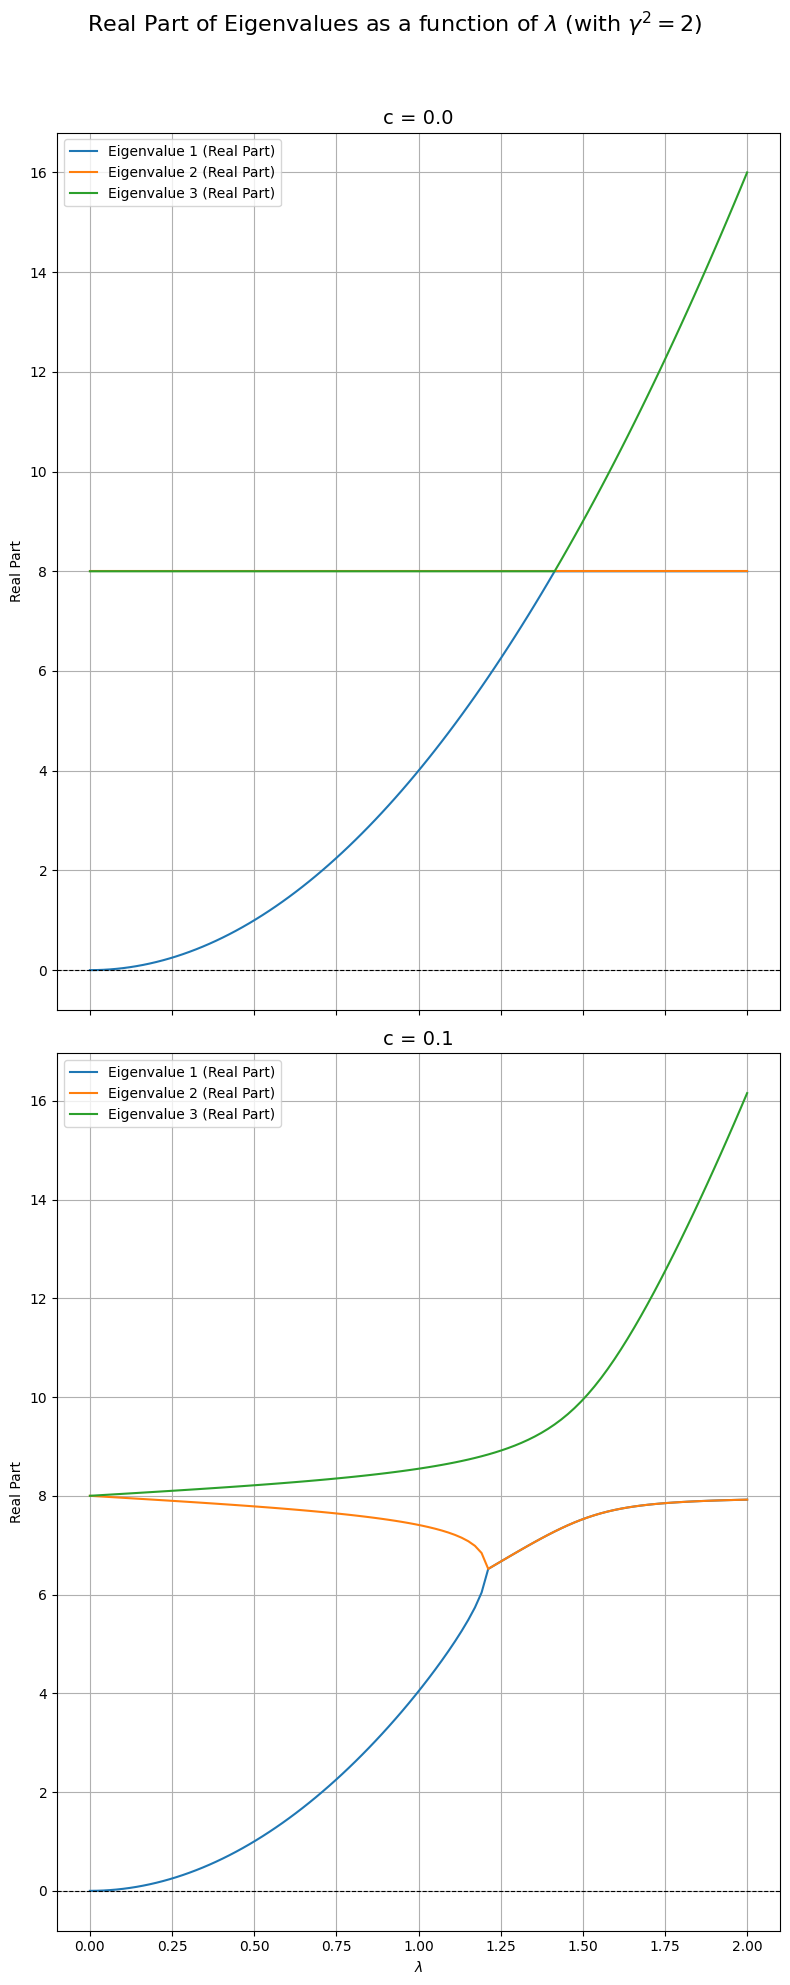

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_eigenvalues(gamma_squared, lamb, c):
    """
    Calculates the real parts of the eigenvalues of matrix A.
    """
    # --- MODIFICATION: Set M=1 as requested ---
    M_inv = 4.

    # Define the matrix A
    A = 4 * np.array([
        [0, -M_inv, 0],
        [1, M_inv * gamma_squared, np.sqrt(gamma_squared) * lamb * c],
        [0, np.sqrt(gamma_squared) * lamb * c, lamb**2]
    ])
    # Calculate eigenvalues
    eigenvals = np.linalg.eigvals(A)
    # Return the sorted real parts of the eigenvalues
    return eigenvals

# --- Configuration ---
c_values = [0., 0.1]
n_points = 100  # Resolution for the lambda axis

# --- MODIFICATION: Set gamma^2 = 2 and create a 1D lambda range ---
gamma_squared_fixed = 1.0
lambda_range = np.linspace(0, 2, n_points)

# --- Create the Plot Grid ---
# One row for each c_value, one column for all three eigenvalues
fig, axs = plt.subplots(len(c_values), 1, figsize=(8, 20), sharex=True)
fig.suptitle('Real Part of Eigenvalues as a function of $\lambda$ (with $\gamma^2=2$)', fontsize=16, y=0.99)

print("Calculating eigenvalues and generating 2D plots...")

# --- Generate Data and Plot ---
for i, c in enumerate(c_values):
    ax = axs[i]
    # Initialize lists to store the eigenvalue results for the current 'c'
    eig1_list, eig2_list, eig3_list = [], [], []

    # Calculate eigenvalues for each point in the lambda range
    for lamb in lambda_range:
        e1, e2, e3 = np.sort(np.real(get_eigenvalues(gamma_squared_fixed, lamb, c)))
        eig1_list.append(e1)
        eig2_list.append(e2)
        eig3_list.append(e3)

    # --- MODIFICATION: Plot the three eigenvalues as 2D lines ---
    ax.plot(lambda_range, eig1_list, label='Eigenvalue 1 (Real Part)')
    ax.plot(lambda_range, eig2_list, label='Eigenvalue 2 (Real Part)')
    ax.plot(lambda_range, eig3_list, label='Eigenvalue 3 (Real Part)')
    
    # Add a horizontal line at y=0 for reference
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

    # Set titles and labels
    ax.set_title(f'c = {c}', fontsize=14)
    ax.set_ylabel('Real Part')
    ax.grid(True)
    ax.legend()

# Set the x-axis label only on the last plot
axs[-1].set_xlabel('$\lambda$')

# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [10]:
import numpy as np
from scipy.linalg import expm

def analyze_matrix(gamma, lamb, c):
    """
    Analyzes the properties of the diffusion matrix A.
    """
    # 1. Define the matrix A with M=1
    A = np.array([
        [0, -1, 0],
        [1, gamma**2, gamma * lamb * c],
        [0, gamma * lamb * c, lamb**2]
    ])

    # 2. Compute eigenvalues and eigenvectors
    eigenvalues, P = np.linalg.eig(A)
    
    # Sort for consistency
    sort_indices = np.lexsort((np.imag(eigenvalues), np.real(eigenvalues)))
    eigenvalues = eigenvalues[sort_indices]
    P = P[:, sort_indices]

    # 3. Compute diagonalization
    D = np.diag(eigenvalues)
    P_inv = np.linalg.inv(P)

    # 4. Package results
    return {
        "matrix_A": A,
        "eigenvalues": eigenvalues,
        "diagonal_matrix_D": D,
        "eigenvector_matrix_P": P,
        "inverse_P": P_inv,
    }

def compute_exp_from_diag(P, D, P_inv, t):
    """
    Computes e^(At) using the diagonalization A = PDP⁻¹.
    """
    eigenvalues = np.diag(D)
    exp_eigenvalues = np.exp(eigenvalues * t)
    exp_Dt = np.diag(exp_eigenvalues)
    exp_At = P @ exp_Dt @ P_inv
    return np.real(exp_At)

# --- 1. SET PARAMETERS AND ANALYZE THE MATRIX ---
gamma_val = np.sqrt(2)
lambda_val = np.sqrt(2)
c_val = 0.5
TIME = 0.001

analysis = analyze_matrix(gamma_val, lambda_val, c_val)

print(f"--- Analysis for gamma^2=2, lambda^2=2, c={c_val} ---")
print("\nOriginal Matrix A:\n", np.round(analysis["matrix_A"], 4))
print("\nEigenvalues (θ):")
for i, eig in enumerate(analysis["eigenvalues"]):
    print(f"  θ_{i+1} = {eig:.4f}")

# --- 2. VERIFY THE DIAGONALIZATION: A = PDP⁻¹ ---
P = analysis["eigenvector_matrix_P"]
D = analysis["diagonal_matrix_D"]
P_inv = analysis["inverse_P"]
A_reconstructed = P @ D @ P_inv

print("\n--- Verification 1: Is A equal to PDP⁻¹? ---")
assert np.allclose(analysis["matrix_A"], A_reconstructed)
print("✅ Yes, the diagonalization correctly reconstructs the original matrix A.")

# --- 3. COMPUTE AND VERIFY THE MATRIX EXPONENTIAL ---
# Method 1: Using your diagonalization
exp_A_diag = compute_exp_from_diag(P, D, P_inv, TIME)

# Method 2: Using the built-in scipy function on the original matrix
exp_A_builtin = expm(analysis["matrix_A"] * TIME)

print("\n--- Verification 2: Comparing Matrix Exponential Methods ---")
print("\nResult from Diagonalization Method (Pe^DtP⁻¹):\n", np.round(exp_A_diag, 4))
print("\nResult from Built-in expm() Method:\n", np.round(exp_A_builtin, 4))

assert np.allclose(exp_A_diag, exp_A_builtin)
print("\n✅ Confirmed: Both methods produce the same matrix exponential.")

--- Analysis for gamma^2=2, lambda^2=2, c=0.5 ---

Original Matrix A:
 [[ 0. -1.  0.]
 [ 1.  2.  1.]
 [ 0.  1.  2.]]

Eigenvalues (θ):
  θ_1 = 0.5804-0.6063j
  θ_2 = 0.5804+0.6063j
  θ_3 = 2.8393+0.0000j

--- Verification 1: Is A equal to PDP⁻¹? ---
✅ Yes, the diagonalization correctly reconstructs the original matrix A.

--- Verification 2: Comparing Matrix Exponential Methods ---

Result from Diagonalization Method (Pe^DtP⁻¹):
 [[ 1.000e+00 -1.000e-03 -0.000e+00]
 [ 1.000e-03  1.002e+00  1.000e-03]
 [ 0.000e+00  1.000e-03  1.002e+00]]

Result from Built-in expm() Method:
 [[ 1.000e+00 -1.000e-03 -0.000e+00]
 [ 1.000e-03  1.002e+00  1.000e-03]
 [ 0.000e+00  1.000e-03  1.002e+00]]

✅ Confirmed: Both methods produce the same matrix exponential.


In [12]:
import sympy

# 1. Define all variables as symbolic objects
# We define them as real and positive where appropriate
t = sympy.Symbol('t', real=True)
beta = 4 #sympy.Symbol('beta', positive=True)
gamma = np.sqrt(2)#sympy.Symbol('gamma', positive=True)
lamb = np.sqrt(2)#sympy.Symbol('lambda', positive=True) # Using 'lamb' as lambda is a keyword
c = 0.5 #sympy.Symbol('c', nonnegative=True)

# 2. Define your matrix A with M=1
A = sympy.Matrix([
    [0, -1, 0],
    [1, gamma**2, gamma * lamb * c],
    [0, gamma * lamb * c, lamb**2]
])

# 3. Define the drift matrix F = -βA
F = -beta * A

# 4. Compute the matrix exponential e^(F*t)
# The .exp() method computes the symbolic matrix exponential
exp_Ft = (F * t).exp()

# --- Print the results ---
print("Matrix F = -βA:")
sympy.pprint(F)

print("\n" + "="*50)
print("\nAnalytical Matrix Exponential e^(Ft):\n")

# Use pretty-printing for a more readable mathematical output
sympy.pprint(exp_Ft)

KeyboardInterrupt: 